# 04 — Concept Bottleneck Inference

Defines and demos the `EMGInferencer` + `ConceptBottleneck` interface that the clinical inference system will call.

**Outputs:** 5 concept scores → clinical distress aggregate (0–10)

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from infer import EMGInferencer, ConceptBottleneck, CONCEPT_NAMES
from simulate import PROFILES

CKPT_PATH  = ROOT / 'results' / 'production-emg-module_best.pt'
STATS_PATH = ROOT / 'results' / 'feat_stats.json'
DATA_DIR   = ROOT / 'data' / 'synthetic'

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

## Load inferencer

In [2]:
inferencer = EMGInferencer.from_checkpoint(CKPT_PATH, STATS_PATH)
bottleneck = ConceptBottleneck()

print(f'Device: {inferencer.device}')
print('Inferencer ready.')

Device: mps
Inferencer ready.


`EMGInferencer` loads checkpoint from `results/production-emg-module_best.pt` and normalization stats from `feat_stats.json`

`ConceptBottleneck` doesn't have any weights yet

## Single-signal demo

One call: raw signal → concept scores → Silverman aggregate.
- takes X[4] (exhausted) and prints all 5 concept scores + aggregate
- concept scores are the 5 intermediate outputs form the CNN before a final decision
- raw EMG -> 5 interpretable values [concept scores] -> distress score
1. `fatigue_prob`: overall muscle fatigue
2. `resp_effort`: amplitude of breathing effort
3. `mdf_slope_norm`: how fast median freq drops over the time series/window
4. `spectral_comp`: ratio of high/low freq energy. low energy = fatigued. shifts down.
5. `entropy`: signal complexity. low = fatigued. regular signal. 

In [3]:
X = np.load(DATA_DIR / 'X.npy')

# Index 4 = exhausted profile (fatigue 0.7→1.0)
signal = X[4]

concepts = inferencer.predict(signal)
agg      = bottleneck.score(concepts)

print('Concept scores:')
for name, val in concepts.to_dict().items():
    print(f'  {name:<22} {val:.4f}')
print(f'\nSilverman aggregate: {agg:.2f} / 10  →  {bottleneck.interpret(agg)}')

Concept scores:
  fatigue_prob           0.9392
  resp_effort            0.8197
  mdf_slope_norm         0.2908
  spectral_comp          0.1977
  entropy                0.2790

Silverman aggregate: 7.15 / 10  →  severe distress


## Concepts across all 5 fatigue profiles

200 samples per profile (indices 0–199 = fresh, 200–399 = mild, …).
Plot mean ± std per concept.

In [4]:
profile_labels = ['Fresh\n(0→0.05)', 'Mild\n(0→0.4)', 'Moderate\n(0.1→0.6)',
                  'Severe\n(0.3→0.8)', 'Exhausted\n(0.7→1.0)']
n_per_profile = 200

all_concepts = []   # [5 profiles, n_per_profile, 5 concepts]
all_scores   = []   # [5 profiles, n_per_profile]

for p in range(5):
    start = p * n_per_profile
    batch_c, batch_s = [], []
    for sig in X[start:start + n_per_profile]:
        c = inferencer.predict(sig)
        batch_c.append(c.to_array())
        batch_s.append(bottleneck.score(c))
    all_concepts.append(np.stack(batch_c))
    all_scores.append(batch_s)

all_concepts = np.array(all_concepts)  # [5, 200, 5]
all_scores   = np.array(all_scores)    # [5, 200]

print('Mean Silverman aggregate per profile:')
for label, scores in zip(profile_labels, all_scores):
    label_flat = label.replace('\n', ' ')
    print(f'  {label_flat:<28}  {np.mean(scores):.2f} ± {np.std(scores):.2f}')

Mean Silverman aggregate per profile:
  Fresh (0→0.05)                4.30 ± 2.32
  Mild (0→0.4)                  4.29 ± 2.34
  Moderate (0.1→0.6)            4.30 ± 2.31
  Severe (0.3→0.8)              4.31 ± 2.33
  Exhausted (0.7→1.0)           4.28 ± 2.33


## Concept heatmap — mean score per profile

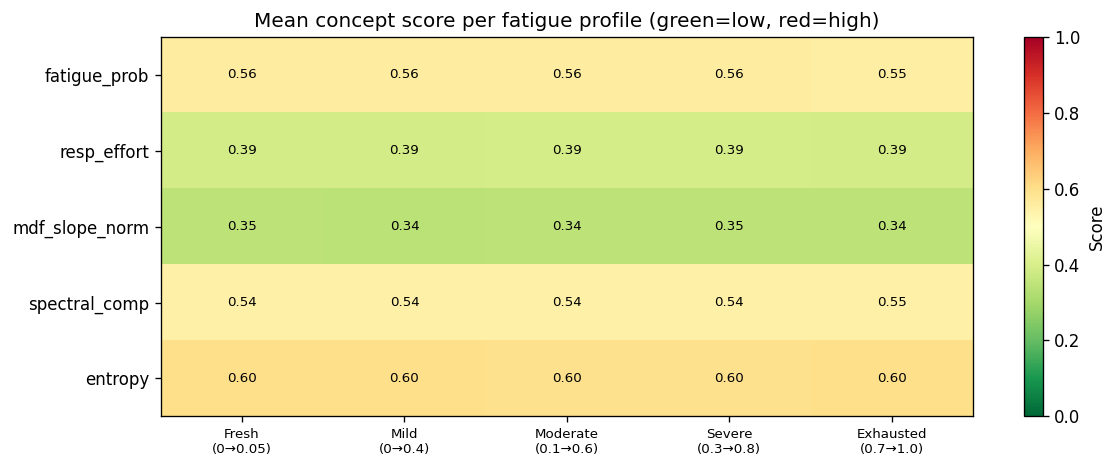

In [5]:
means = all_concepts.mean(axis=1)  # [5 profiles, 5 concepts]

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(means.T, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=1)

ax.set_xticks(range(5))
ax.set_xticklabels(profile_labels, fontsize=8)
ax.set_yticks(range(5))
ax.set_yticklabels(CONCEPT_NAMES)
ax.set_title('Mean concept score per fatigue profile (green=low, red=high)')

for i in range(5):
    for j in range(5):
        ax.text(i, j, f'{means[i, j]:.2f}', ha='center', va='center', fontsize=8,
                color='white' if means[i, j] > 0.6 or means[i, j] < 0.3 else 'black')

plt.colorbar(im, ax=ax, label='Score')
plt.tight_layout()

## Silverman aggregate distribution per profile

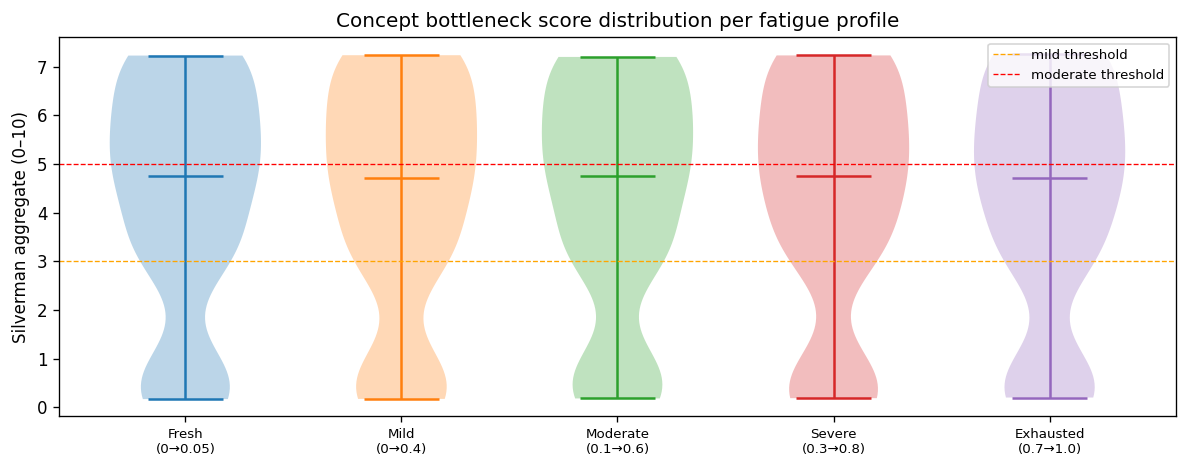

In [6]:
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, 5))

fig, ax = plt.subplots(figsize=(10, 4))
for i, (label, scores, c) in enumerate(zip(profile_labels, all_scores, colors)):
    ax.violinplot(scores, positions=[i], widths=0.7, showmedians=True)

patches = [mpatches.Patch(color=c, label=l.replace('\n', ' '))
           for c, l in zip(colors, profile_labels)]
ax.set_xticks(range(5))
ax.set_xticklabels(profile_labels, fontsize=8)
ax.set_ylabel('Silverman aggregate (0–10)')
ax.set_title('Concept bottleneck score distribution per fatigue profile')
ax.axhline(3, color='orange', lw=0.8, ls='--', label='mild threshold')
ax.axhline(5, color='red',    lw=0.8, ls='--', label='moderate threshold')
ax.legend(fontsize=8)
plt.tight_layout()

## NOA integration contract

```python
from infer import EMGInferencer, ConceptBottleneck

# Boot once at startup
inferencer = EMGInferencer.from_checkpoint('results/production-emg-module_best.pt',
                                           'results/feat_stats.json')
bottleneck = ConceptBottleneck()

# Called per window (30 s, 1 kHz, float32 numpy array)
def assess(raw_emg: np.ndarray) -> dict:
    concepts = inferencer.predict(raw_emg)
    score    = bottleneck.score(concepts)
    return {
        'concepts':   concepts.to_dict(),
        'silverman':  score,
        'label':      bottleneck.interpret(score),
    }
```

**Thresholds** (defined in `ConceptBottleneck`):
| Score | Interpretation |
|-------|----------------|
| < 3   | minimal distress |
| 3–5   | mild distress |
| 5–7   | moderate distress |
| ≥ 7   | severe distress |